In [1]:
#    Define input file for BOUT++

import numpy as np
import scipy
import xbout
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 200  
plt.ioff()
#%load_ext autoreload
#%autoreload 2
params = {'legend.fontsize': 8,
'legend.title_fontsize': 8,
'figure.figsize': (4.8, 4.8),
'axes.labelsize': 12,
'axes.titlesize': 15,
'xtick.labelsize':8,
'ytick.labelsize':8,
'font.family': 'serif',
'text.usetex': False}
plt.rcParams.update(params)

In [2]:

def write_BOUT_inp(grid,diffusion,dpar):
    # Normalization, beacuse x does indeed not go from 0 to 1, this screws up
    # the calculation for the perp derivatives
    

    
    cont = f"""
nout = 50
timestep = (20.0*pi)/nout

grid = "{grid}"

xl=x
yl=y
zl=z
diffusion={diffusion}
dpar={dpar}
[mesh:paralleltransform]
type = fci


[input]
error_on_unused_options=false


[mesh]

symmetricGlobalX = true

extrapolate_y = false

##################################################
[mesh:ddx]   # Methods used for perp (x) derivative terms

first = C4
second = C4
upwind = U1
flux = SPLIT

[mesh:ddy]   # Methods used for parallel (y) derivative terms

first = C4
second = C4
upwind = U1
flux = SPLIT

[mesh:ddz]   # Methods used for perp (z) derivative terms

first = C4
second = C4
upwind = U1
flux = SPLIT

[solver]

type=cvode
atol = 1e-15 # absolute tolerance
rtol = 1e-8  # relative tolerance
mxstep = 1000000


[Ne]

bndry_xin = dirichlet
bndry_xout = dirichlet
bndry_par_all = parallel_neumann_o1

    """
    return cont

def gridfile_string(nx,ny,nz,distortion,directory,rho_1=0.0,rho_2=0.4,rho_3=0.6,Ly=6.283,
                    B0=1.0,q0=8.0,q1=-0.2,k_inner=3,k_outer=2,amp_inner=0.2,amp_outer=0.5):
    content = f"{directory}cor_BAD_mms_Axial_Circle_{nx}_{ny}_{nz}_{rho_1}_{rho_2}_{rho_3}_{np.round(Ly,3)}_{B0}_{q0}_{q1}_{distortion}_{k_inner}_{k_outer}_{amp_inner}_{amp_outer}.fci.grid.nc"
    return content


def write_slurmfile(id,nodes,ntasks_per_node, mem,time_h,time_min,
                   executable,directory):
    content=f"""#!/bin/bash -l                                                                                                                                        
# Standard output and error:                                                                                                                          
#SBATCH -o ./job_hybrid.out.%j                                                                                                                        
#SBATCH -e ./job_hybrid.err.%j                                                                                                                        
# Initial working directory:                                                                                                                          
#SBATCH -D ./                                                                                                                                         
# Job Name:                                                                                                                                           
#SBATCH -J MMS_distorted_grid_{int(id)}                                                                                                                         
#                                                                                                                                                     
# Number of nodes and MPI tasks per node:                                                                                                             
#SBATCH --nodes={nodes}                                                                                                                                    
#SBATCH --ntasks-per-node={int(ntasks_per_node)}                                                                                                                          
#SBATCH --mem={int(mem)}GB                                                                                                                                    

# for OpenMP:                                                                                                                                         
#SBATCH --cpus-per-task=1                                                                                                                             
#SBATCH --mail-type=all                                                                                                                               
#SBATCH --mail-user=toto@ipp.mpg.de                                                                                                                   
#                                                                                                                                                     
# Wall clock limit (max. is 24 hours):                                                                                                                
#SBATCH --time={int(time_h)}:{int(time_min)}:00                                                                                                                               
set -x
# Load compiler and MPI modules (must be the same as used for compiling the code)                                                                     
module purge
module load gcc/13 openmpi/4.1 hdf5-serial/1.14.1 netcdf-serial/4.9.2 fftw-mpi/3.3.10 anaconda/3/2021.11 mkl/2024.0

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# For pinning threads correctly:                                                                                                                      
export OMP_PLACES=cores

# Run the program                                                                                                                                     

srun {executable} -d {directory} $@
    
    """
    return content

In [3]:
dis=1
#dis=1

grids=[]

grids.append([36,4,128,dis])
grids.append([68,8,256,dis])
grids.append([100,12,384,dis])
grids.append([132,16,512,dis])
grids.append([260,32,1024,dis])

cores=[16,64,128,128,128]
comptimes=[1,1,2,4,4]
nodes=[1,1,1,2,4]


maindir="/u/toto/soft/hermes-2-new/hermes-2/MMS/distorted_grid/"

In [4]:


for i in range(len(grids)):
    id = i
    gridfilename=gridfile_string(grids[i][0],grids[i][1],grids[i][2],grids[i][3],maindir)

    BOUTinp=write_BOUT_inp(grid=gridfilename,diffusion=0.001,dpar=1.0)
    exec_dir=maindir+"build_fast/distorted_grid"
    directory=f"{maindir}data_{id}"
    slurmbatch=write_slurmfile(id,nodes[i],cores[i],64,comptimes[i],0,exec_dir,directory)

    with open(f"data_{int(id)}/BOUT.inp", "w") as file:
        file.write(BOUTinp)

    with open(f"data_{int(id)}/slurmbatch", "w") as file:
        file.write(slurmbatch)

In [15]:
analyze=True
if (analyze)==True:
    L2s={}
    L2infs={}
    fitcofs={}
    vars=["Ne"]
    for var in vars:
        L2={}
        Linf={}
        yspacings={}
        xfit=[]
        yfit=[]
        for i in [0,1,2,3]: 
            id = i
            #try:
            gridfilename=gridfile_string(grids[i][0],grids[i][1],grids[i][2],grids[i][3],maindir)
            results=xbout.open_boutdataset(datapath=f"{maindir}/data_{i}/BOUT.dmp.nc",
                                  gridfilepath=gridfilename,geometry="fci")
            yspacings[str(id)]=results.y.size
            xfit.append(results.y.size)
            nt=results["t"].size
            t2=None
            xcut=2
            L2[str(id)]=np.sqrt(((results[var]-results[var+"_solution"])**2).isel(x=slice(xcut,-xcut),t=slice(None,t2)).mean()).values
            yfit.append(L2[str(id)])
            Linf[str(id)]=(results[var]-results[var+"_solution"]).isel(x=slice(xcut,-xcut),t=slice(None,t2)).max()
            #except:
                #print(f"Failed at {i}")

        initial_guesses = [5, -4.0]
        xfit=1.0/np.array(xfit)
        yfit=np.array(yfit)

        def fitfunction(x,a,b):
            return a*x**b

        popt_N, pcov_N = curve_fit(fitfunction, xfit,yfit, maxfev=1000,p0=initial_guesses)
        L2s[var]=L2
        L2infs[var]=Linf
        fitcofs[var]=popt_N



Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 36, y: 4, z: 128, t: 51)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndarray>
  * t                   (t) float64 0.0 1.257 2.513 3.77 ... 60.32 61.58 62.83
    R                   (x, y, z) float64 0.4 0.3992 0.3968 ... 0.5935 0.5984
    Z                   (x, y, z) float64 1.301e-18 0.02549 ... -0.04412
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34 35
  * y                   (y) float64 0.7854 2.356 3.927 5.498
  * z                   (z) float64 0.0 0.04909 0.09817 ... 6.136 6.185 6.234
Data variables: (12/42)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndar

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 132, y: 16, z: 512, t: 51)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(132, 16, 512), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(132, 16, 512), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(132, 16, 512), meta=np.ndarray>
  * t                   (t) float64 0.0 1.257 2.513 3.77 ... 60.32 61.58 62.83
    R                   (x, y, z) float64 0.4 0.3999 0.3998 ... 0.5996 0.5999
    Z                   (x, y, z) float64 1.518e-18 0.006381 ... -0.01104
  * x                   (x) int64 0 1 2 3 4 5 6 ... 125 126 127 128 129 130 131
  * y                   (y) float64 0.1963 0.589 0.9817 ... 5.301 5.694 6.087
  * z                   (z) float64 0.0 0.01227 0.02454 ... 6.246 6.259 6.271
Data variables: (12/42)
    Bxy                 (x, y, z) float64 dask.array<chunksize=

<IPython.core.display.Javascript object>


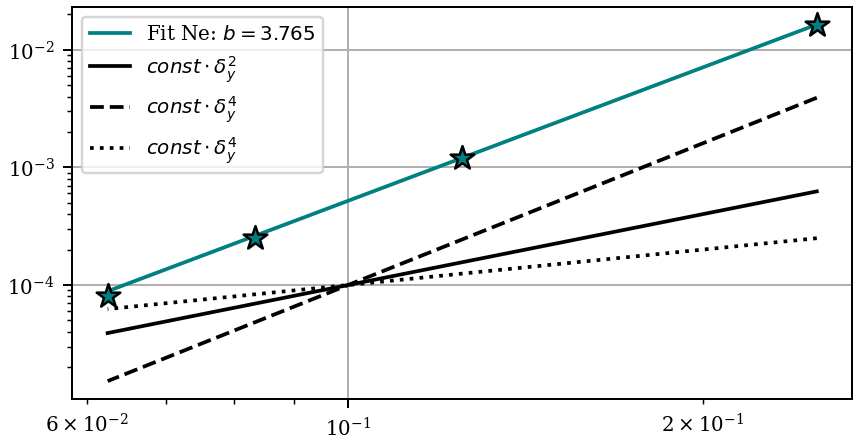

In [16]:
if (analyze)==True:
    cols={}
    cols[vars[0]]="Teal"
    %matplotlib notebook
    plt.close()
    fig,(ax) = plt.subplots(1,1,figsize=(4.8,2.5),layout="constrained")
    for var in vars:
        L2=L2s[var]
        popt_N=fitcofs[var]
        for key in L2:
            ax.scatter(1.0/yspacings[key],L2[key],color=cols[var],marker="*",s=100,edgecolor="black",zorder=10)
        ax.plot(xfit,fitfunction(xfit, *popt_N),label=f'Fit {var}: $b={popt_N[1]:.3f}$',color=cols[var])

    
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.plot(xfit,1e-2*xfit**2,color="black",label=r"$const \cdot \delta_y^2$")
    ax.plot(xfit,1*xfit**4,color="black",label=r"$const \cdot \delta_y^4$",linestyle="dashed")
    ax.plot(xfit,1e-3*xfit**1,color="black",label=r"$const \cdot \delta_y^4$",linestyle="dotted")
    ax.legend()
    plt.show()

In [7]:

#LOAD MANUAL STUFF
offset=2
maindir="/u/toto/soft/hermes-2-new/hermes-2/MMS/distorted_grid/"

id=0
gridfilename=gridfile_string(grids[id][0],grids[id][1],grids[id][2],grids[id][3],maindir)


df=xbout.open_boutdataset(datapath=maindir+f"data_{id}/"+"BOUT.dmp.nc",
                          gridfilepath=gridfilename,geometry="fci").isel(x=slice(offset,-offset))
grid = xr.open_dataset(gridfilename).isel(x=slice(offset,-offset))

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 36, y: 4, z: 128, t: 51)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndarray>
  * t                   (t) float64 0.0 1.257 2.513 3.77 ... 60.32 61.58 62.83
    R                   (x, y, z) float64 0.4 0.3992 0.3968 ... 0.5935 0.5984
    Z                   (x, y, z) float64 1.301e-18 0.02549 ... -0.04412
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34 35
  * y                   (y) float64 0.7854 2.356 3.927 5.498
  * z                   (z) float64 0.0 0.04909 0.09817 ... 6.136 6.185 6.234
Data variables: (12/42)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(36, 4, 128), meta=np.ndar

<IPython.core.display.Javascript object>


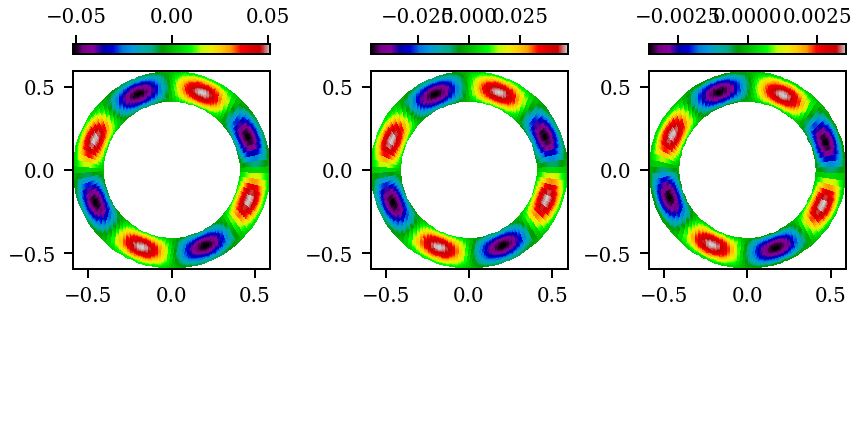

/tmp/ipykernel_3583964/3075182251.py:9: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),cmap="nipy_spectral")
/tmp/ipykernel_3583964/3075182251.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=thist),cmap="nipy_spectral")
/tmp/ipykernel_3583964/3075182251.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may l

In [8]:
%matplotlib notebook
plt.close()
thist=-25
thisy=0

Field="Ne"

fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(4.8,2.4),layout="constrained")
a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),cmap="nipy_spectral")
plt.colorbar(a,location="top")
ax1.set_aspect("equal")

b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=thist),cmap="nipy_spectral")
plt.colorbar(b,location="top")
ax2.set_aspect("equal")

c=ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),(df[Field]-df[Field+"_solution"]).isel(y=thisy,t=thist),cmap="nipy_spectral")
plt.colorbar(c,location="top")
ax3.set_aspect("equal")

plt.show()

<IPython.core.display.Javascript object>


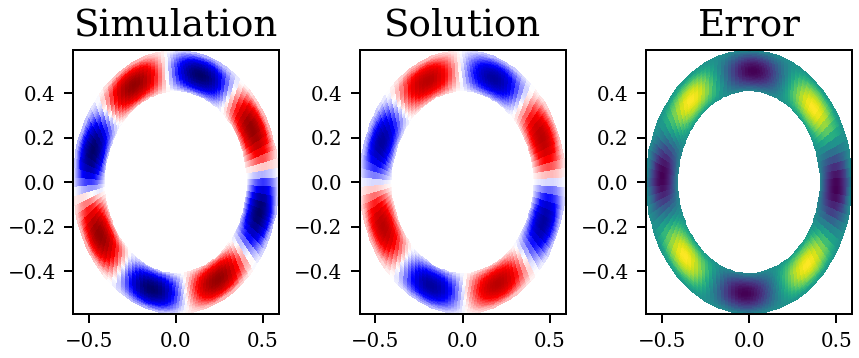

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

/tmp/ipykernel_3583964/639955729.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
/tmp/ipykernel_3583964/639955729.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or 

In [10]:
from matplotlib.animation import FuncAnimation
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(4.8,2.0),layout="constrained")
line, = ax1.plot([], [], lw=2)  # Create an empty line object to update during animation

thisy=1
# Define the initialization function
def init():
    line.set_data([], [])
    return line,

Field = "Ne"
# Define the update function for each frame
def update(frame):
    ax1.cla()
    ax2.cla()
    ax3.cla()
    vmin=np.min(df[Field+"_solution"].isel(y=thisy).values)
    vmax=np.max(df[Field+"_solution"].isel(y=thisy).values)
    ax1.set_title("Simulation")
    ax2.set_title("Solution")
    ax3.set_title("Error")
    ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
    ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field+"_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
    ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),(df[Field]-df[Field+"_solution"]).isel(y=thisy,t=frame))
    
    return line,

# Set up and run the animation
frames = (df["t"].size)  # Number of time steps
anim = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True,interval=100)
#anim.save("/u/toto/MMS_Loki/animation.gif", writer="pillow", fps=10)
# Display the animation in the notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

In [19]:
(df[Field]-df[Field+"_solution"]).isel(z=0,t=20,y=0).values

array([-5.81246490e-16,  0.00000000e+00, -1.26616540e-06, -2.48985736e-06,
       -3.67114677e-06, -4.81011723e-06, -5.90686125e-06, -6.96148085e-06,
       -7.97409159e-06, -8.94481858e-06, -9.87379911e-06, -1.07611856e-05,
       -1.16071446e-05, -1.24118571e-05, -1.31755149e-05, -1.38983231e-05,
       -1.45805073e-05, -1.52223080e-05, -1.58239809e-05, -1.63857986e-05,
       -1.69080491e-05, -1.73910374e-05, -1.78350859e-05, -1.82405364e-05,
       -1.86077495e-05, -1.89371014e-05, -1.92289857e-05, -1.94838157e-05,
       -1.97020226e-05, -1.98840588e-05, -2.00303966e-05, -2.01415230e-05,
       -2.02179451e-05, -2.02601896e-05, -2.02688003e-05, -2.02443428e-05,
       -2.01874033e-05, -2.00985861e-05, -1.99785105e-05, -1.98278123e-05,
       -1.96471539e-05, -1.94372180e-05, -1.91986990e-05, -1.89323097e-05,
       -1.86387833e-05, -1.83188720e-05, -1.79733457e-05, -1.76029914e-05,
       -1.72086145e-05, -1.67910372e-05, -1.63510981e-05, -1.58896519e-05,
       -1.54075693e-05, -

<IPython.core.display.Javascript object>


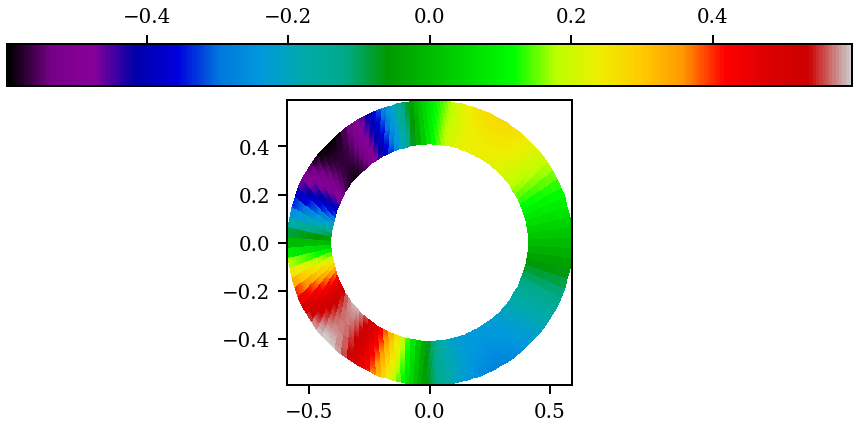

/tmp/ipykernel_3583964/707043952.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  a=ax1.pcolormesh(grid.R.isel(y=thisy),grid.Z.isel(y=thisy),grid.g_13.isel(y=thisy),cmap="nipy_spectral")


In [9]:
thisy=0
fig,(ax1)=plt.subplots(1,1,figsize=(4.8,2.4),layout="constrained")
a=ax1.pcolormesh(grid.R.isel(y=thisy),grid.Z.isel(y=thisy),grid.g_13.isel(y=thisy),cmap="nipy_spectral")
plt.colorbar(a,location="top")
ax1.set_aspect("equal")

<IPython.core.display.Javascript object>


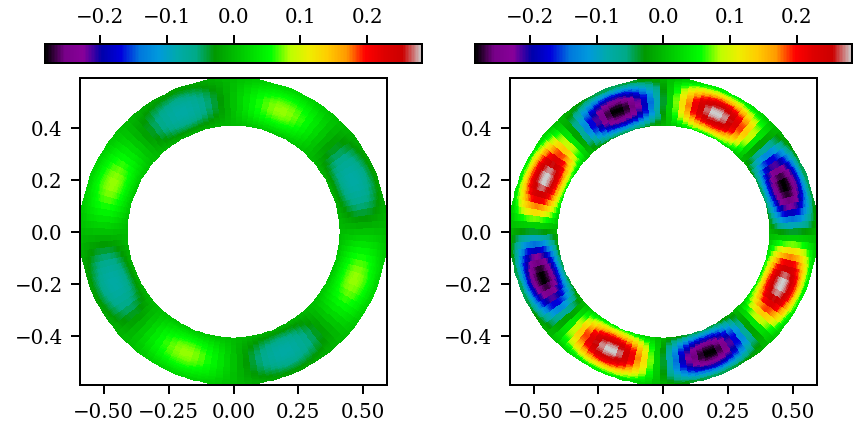

/tmp/ipykernel_3327075/3320652107.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  a=ax1.pcolormesh(grid.R.isel(y=thisy),grid.Z.isel(y=thisy),df["debug_diffusion"].isel(y=thisy,t=thist),
/tmp/ipykernel_3327075/3320652107.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  b=ax2.pcolormesh(grid.R.isel(y=thisy),grid.Z.isel(y=thisy),df["debug_pardiffusion"].isel(y=thisy,t=thist),


In [10]:
thisy=0
thist=20
plt.close("all")
vmin=np.min(df["debug_pardiffusion"].isel(y=thisy,t=thist).values)
vmax=np.max(df["debug_pardiffusion"].isel(y=thisy,t=thist).values)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(4.8,2.4),layout="constrained")
a=ax1.pcolormesh(grid.R.isel(y=thisy),grid.Z.isel(y=thisy),df["debug_diffusion"].isel(y=thisy,t=thist),
                 cmap="nipy_spectral",vmin=vmin,vmax=vmax)
plt.colorbar(a,location="top")

b=ax2.pcolormesh(grid.R.isel(y=thisy),grid.Z.isel(y=thisy),df["debug_pardiffusion"].isel(y=thisy,t=thist),
                 cmap="nipy_spectral",vmin=vmin,vmax=vmax)
plt.colorbar(b,location="top")

ax1.set_aspect("equal")
ax2.set_aspect("equal")